# Huấn luyện KNN (K láng giềng gần nhất)

**KNN** dự đoán dựa trên k ca bệnh giống nhất trong dữ liệu.

> Nhớ chạy `02_tien_xu_ly/tien_xu_ly_data.ipynb` trước để có `features.csv`.

## Bước 1. Đọc dữ liệu đã tiền xử lý

In [1]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Đọc dữ liệu đã tiền xử lý (chạy notebook tien_xu_ly_data.ipynb trước)
data = pd.read_csv("../01_data/processed/features.csv")

X = data.drop(columns=["Benh"])     # các cột triệu chứng
y = data["Benh"]                    # nhãn bệnh (dạng chữ)

# Đổi nhãn chữ -> số
le = LabelEncoder()
y_num = le.fit_transform(y)

# Chia tập huấn luyện / kiểm tra (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_num, test_size=0.2, random_state=42, stratify=y_num)
print("Train:", X_train.shape, "| Test:", X_test.shape, "| Số bệnh:", len(le.classes_))


Train: (1680, 37) | Test: (420, 37) | Số bệnh: 14


## Bước 2. Huấn luyện và đánh giá

In [2]:
from sklearn.metrics import accuracy_score, classification_report

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Độ chính xác trên tập test:", round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))


Độ chính xác trên tập test: 0.979

                precision    recall  f1-score   support

       Cảm cúm       0.94      0.97      0.95        30
      Cảm lạnh       0.97      0.97      0.97        30
        Dị ứng       0.91      1.00      0.95        30
     Hen suyễn       1.00      1.00      1.00        30
       Sốt rét       0.94      1.00      0.97        30
Sốt xuất huyết       1.00      1.00      1.00        30
      Thủy đậu       1.00      0.97      0.98        30
 Tiêu chảy cấp       1.00      0.97      0.98        30
   Viêm dạ dày       1.00      0.97      0.98        30
     Viêm họng       1.00      0.97      0.98        30
 Viêm phế quản       0.97      1.00      0.98        30
     Viêm phổi       1.00      0.97      0.98        30
    Viêm xoang       1.00      0.97      0.98        30
   Đau nửa đầu       1.00      0.97      0.98        30

      accuracy                           0.98       420
     macro avg       0.98      0.98      0.98       420
  weighted 

## Bước 3. Đường cong học tập theo tham số

Thử nhiều giá trị của **`n_neighbors`** để xem mô hình tốt nhất ở đâu.
- Đường **Train** cao mà **Kiểm tra (CV)** thấp ⇒ **quá khớp** (overfitting).
- Cả hai cùng thấp ⇒ **chưa khớp** (underfitting).


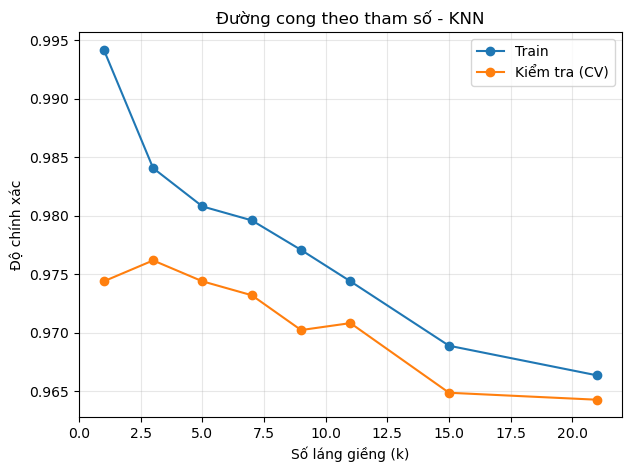

Giá trị n_neighbors tốt nhất: 3


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve

gia_tri = [1, 3, 5, 7, 9, 11, 15, 21]
train_sc, val_sc = validation_curve(
    KNeighborsClassifier(), X_train, y_train,
    param_name="n_neighbors", param_range=gia_tri,
    cv=5, scoring="accuracy")

plt.figure(figsize=(7,5))
plt.plot(gia_tri, train_sc.mean(axis=1), "o-", label="Train")
plt.plot(gia_tri, val_sc.mean(axis=1), "o-", label="Kiểm tra (CV)")

plt.xlabel("Số láng giềng (k)"); plt.ylabel("Độ chính xác")
plt.title("Đường cong theo tham số - KNN")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

tot_nhat = gia_tri[int(np.argmax(val_sc.mean(axis=1)))]
print("Giá trị n_neighbors tốt nhất:", tot_nhat)


## Bước 4. Đường cong học tập theo số lượng mẫu

Xem mô hình học tốt hơn khi có **nhiều dữ liệu** hơn không.


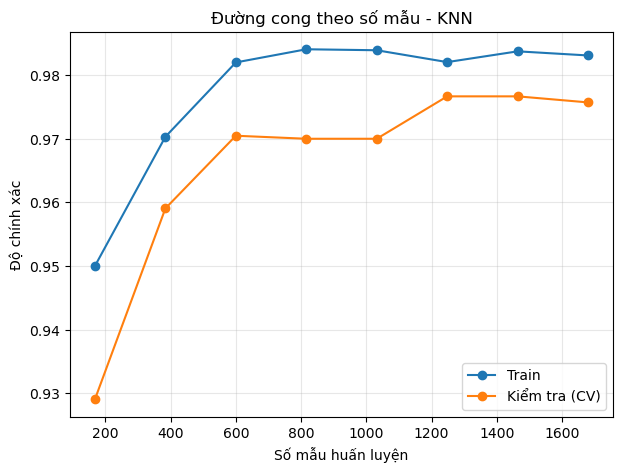

In [4]:
from sklearn.model_selection import learning_curve

sizes, train_sc2, val_sc2 = learning_curve(
    model, X, y_num, cv=5, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 8))

plt.figure(figsize=(7,5))
plt.plot(sizes, train_sc2.mean(axis=1), "o-", label="Train")
plt.plot(sizes, val_sc2.mean(axis=1), "o-", label="Kiểm tra (CV)")
plt.xlabel("Số mẫu huấn luyện"); plt.ylabel("Độ chính xác")
plt.title("Đường cong theo số mẫu - KNN")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()


## Bước 5. Lưu mô hình

In [5]:
import pickle
with open("knn_model.pkl", "wb") as f:
    pickle.dump({"model": model, "label_encoder": le}, f)
print("Đã lưu knn_model.pkl")


Đã lưu knn_model.pkl
